## Base de datos:
La base de datos corresponde al [Bank Marketing Dataset](https://api.rpubs.com/pacoperez/328928), que pertenece al repositorio de ML del Center for Machine Learning and Intelligent Systems de la University of California, Irvine. 

### Sobre la base de datos: 
Los datos incluidos en este dataset pertenecen a campañas de marketing directo de una instutución bancaria portuguesa. Estas campañas de marketing se hicieron en base a llamadas telefónicas que, con frecuencia, necesitaron ser más de una para conocer si el producto (un depósito a plazo) fue finalmente suscrito o no.
* **Objetivo:** mediante los distintos modelos de clasificacción. Predecir si el cliente suscribira a un deposito a plazo o no. Analizar y medir la performance de los distintos modelos utilizados. 

### Atributos/Variables:


* **Cliente**
    * **age  [numérica]:** edad del cliente
    * **job [categórica]:** tipo de trabajo ‘admin.’, ‘blue-collar’, ‘entrepreneur’, ‘housemaid’, ‘management’, ‘retired’, ‘self-employed’, ‘services’, ‘student’, ‘technician’, ‘unemployed’, ‘unknown’
    * **marital [categórica]:** estado civil ‘divorced’, ‘married’, ‘single’, ‘unknown’; Note: ‘divorced’ means divorced or widowed
    * **education [categorical]:** nivel de estudios ‘basic.4y’, ‘basic.6y’, ‘basic.9y’, ‘high.school’, ‘illiterate’, ‘professional.course’, ‘university.degree’, ‘unknown’.
    * **default [categórica]:** ¿tiene crédito pendiente de pago? ‘no’, ‘yes’, ‘unknown’
    * **housing [categórica]:** ¿tiene un préstamos hipotecario? ‘no’, ‘yes’, ‘unknown’
    * **loan [categórica]:** ¿tiene un préstamo personal? ‘no’, ‘yes’, ‘unknown’
    
    
* **Último contacto de la campaña actual** 
    * **contact [binaria]:** tipo de comunicaión mediante la que se ha contactado ‘cellular’, ‘telephone’
    * **month [categórica]:** mes del año del último contacto categorical: ‘jan’, ‘feb’, ‘mar’, …, ‘nov’, ‘dec’
    * **day_of_week [categórica]:** día de la semana del último contacto ‘mon’, ‘tue’, ‘wed’, ‘thu’, ‘fri’)
    * **duration [numérica]:** duración de la última comunicación, en segundos (Importante: este atributo tiene una fuerte relación con la variable de salida (e.g., si duration=0 entonces y=‘no’). La duración no se puede conocer antes de realizar la llamada y, además, tras finalizar ésta se conocerá el valor de y. Por tanto, este atributo debería ser incluído sólo como referencia y eliminado si la intención es obtener un modelo predictivo realista.
    

* **Otros atributos**
    * **campaign [numérica]:** cuántas veces que se ha contactado con este cliente durante la campaña actual (incluída la última llamada)
    * **pdays [numérica]: ** días que han pasado desde la última vez que se contactó al cliente por una campaña anterior. Importante: 999 significa que el cliente no ha sido contactado con anterioridad (ésta es la primera vez que se contacta al cliente (para una campaña publicitaria)
    * **previous [numérica]:** cuántas veces que se ha contactado con este cliente con anterioridad a esta campaña por cualquier motivo
    * **poutcome [categórica]:** resultado de la anterior campaña de marketing ‘failure’, ‘nonexistent’, ‘success’)
    
    
* **Contexto socioeconómico**
    * **emp.var.rate [numérica]:** tasa de variación de empleo (indicador trimestral)
    * **cons.price.idx [numérica]:** indice de precios al consumidor (indicador mensual)
    * **cons.conf.idx [numérica]:** indice de confianza del consumidor (indicador mensual)
    * **euribor3m [numérica]:** euribor a 3 meses (indicador diario)
    * **nr.employed [numérica]:** número de empleados (indicador trimestral)


* **Variable de salida (target deseados)**
    * **y [binaria]:** ¿ha suscrito el cliente el depósito a plazo ofertado? ‘yes’, ‘no’


## 4. Pre-procesamiento
Una vez descargada la base, lo primero que debemos hacer es hacer un pre-procesamiento de la misma. Explorarla y verificar que la misma no contenga inconsistencias que nos dificulten poder realizar los procedimientos esperados. 

### 4.1. Exploramos la base

In [1]:
# Importamos pandas, libreria que nos permitira leer el archivo y manipularlo facilmente. 
# Importamos matplotlib.pyplot, libreria que nos permitira realizar graficos. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Leemos el archivo, y leemos los primeros 10 registros. 
df = pd.read_csv('../input/banco-propension/bank-additional-full.csv', sep = ";")
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
#Hacemos resumen de los datos
df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [4]:
#Exploramos el formato de cada variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Cantidad de registros y columnas
df.shape

(41188, 21)

### Factorización y eliminacion de variables

Observamos que la variable pdays contiene valores del 0 al 27 y luego 999 para los casos en lo que nunca hubo comunicación. Por lo cual pasaremos esto a una variable categorica para poder representarlo de una manera mas simple.

In [6]:
df['pdays'].value_counts(dropna=False).sort_index()

0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: pdays, dtype: int64

In [7]:
#Construimos una función que dependiendo de la cantidad de dias le asigne una semana.
def asigneWeek(days):
    if days < 7:
        return('Week 1')
    elif days < 14:
        return('Week 2')
    elif days < 21:
        return('Week 3')
    elif days < 28:
        return('Week 4')
    else:
        return('Never')
    
#Creamos la columna prev.campaign mapeando la funcion asigneWeek a 'pdays'    
df['prev.campaign'] = df['pdays'].apply(asigneWeek)
#Verificamos su funcionamiento
df['prev.campaign'].value_counts()

Never     39673
Week 1     1117
Week 2      316
Week 3       74
Week 4        8
Name: prev.campaign, dtype: int64

In [8]:
# Eliminamos la variable pdays, ya que no la necesitamos mas y ensuciaria el modelo. 
# Eliminamos la variable duration, ya que como se dijo mas arriba. La duración no se puede conocer antes de realizar 
# la llamada y, además, tras finalizar ésta se conocerá el valor de y. Por tanto, este atributo debería ser incluído 
# sólo como referencia y eliminado si la intención es obtener un modelo predictivo realista.

df = df.drop(['duration','pdays'], axis=1)
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'prev.campaign'],
      dtype='object')

### Missing values (Imputacion)

Observamos que la base tiene asignado los valores missing como "unknown", por lo cual remplazaremos esos valores por "NaN" (Not a Numer) valor Missing para Python, de forma tal de poder realizar los procedimientos correspondientes para darles tratamiento a los missing values. 


In [9]:
#Primero recorremos las 21 variables para remplazar los valores unknown por NA
df = df.replace({'unknown':np.nan})

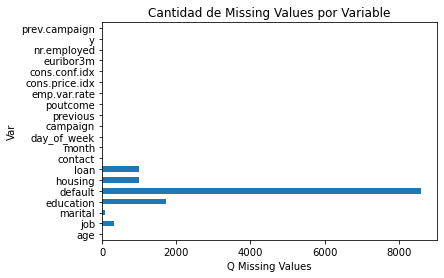

In [10]:
#Corremos un grafico de barra para poder ver la cantidad de missing values de cada variable. 
result = df.isna().sum()
result.plot(kind='barh')
plt.ylabel("Var")
plt.xlabel("Q Missing Values")
plt.title("Cantidad de Missing Values por Variable")
plt.show()


In [11]:
#Observamos que las variables que tienen missing values son las siguientes
result[result > 0]

job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

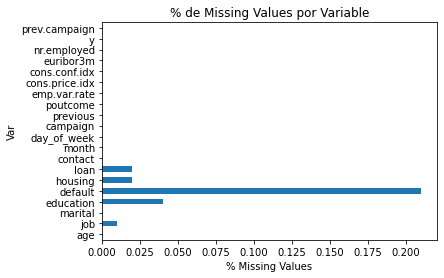

In [12]:
#Si lo vemos en porcentajes seria los siguiente
result = (df.isna().sum()/df.shape[0]).round(2)
result.plot(kind='barh')
plt.ylabel("Var")
plt.xlabel("% Missing Values")
plt.title("% de Missing Values por Variable")
plt.show()


In [13]:
# En modo de tabla
result[result>0]

job          0.01
education    0.04
default      0.21
housing      0.02
loan         0.02
dtype: float64

Observamos que la variable **default** tiene un **21%** de missing values, por lo cual decidimos no utilizarla para el modelo y la borramos del dataframe. 

In [14]:
df = df.drop('default', axis=1)
df.columns

Index(['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'prev.campaign'],
      dtype='object')

Con respecto a las demas variables con missing values, primer observamos brevemente la distribucion que tienen y cuanto representan los missings.  

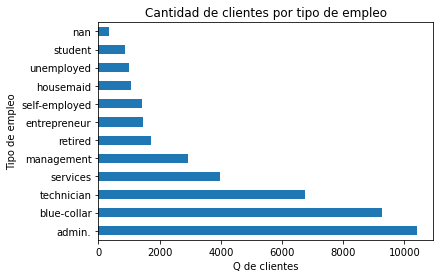

In [15]:
# Distribucion de la variable 'job'
result = df['job'].value_counts(dropna=False)
result.plot(kind='barh')
plt.ylabel("Tipo de empleo")
plt.xlabel("Q de clientes")
plt.title("Cantidad de clientes por tipo de empleo")
plt.show()


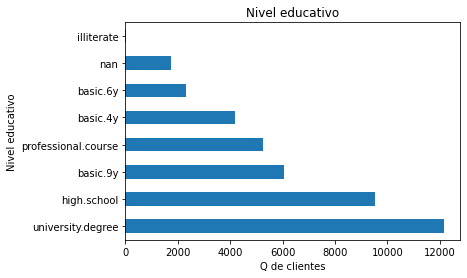

In [16]:
#Distribucion de la variable education
result = df['education'].value_counts(dropna=False)
result.plot(kind='barh')
plt.ylabel("Nivel educativo")
plt.xlabel("Q de clientes")
plt.title("Nivel educativo")
plt.show()


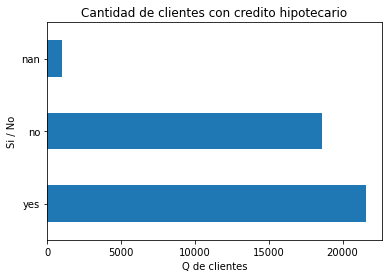

In [17]:
#Distribucion de la variable education
result = df['housing'].value_counts(dropna=False)
result.plot(kind='barh')
plt.ylabel("Si / No")
plt.xlabel("Q de clientes")
plt.title("Cantidad de clientes con credito hipotecario")
plt.show()

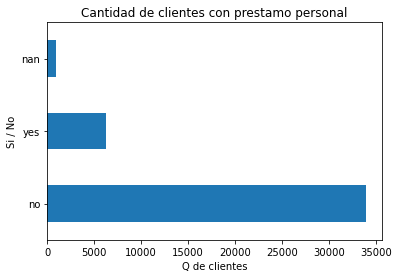

In [18]:
#Distribucion de la variable 'loan'
result = df['loan'].value_counts(dropna=False)
result.plot(kind='barh')
plt.ylabel("Si / No")
plt.xlabel("Q de clientes")
plt.title("Cantidad de clientes con prestamo personal")
plt.show()

### Imputacion de Missing Values: 
Para no perder la información contenida en los registros con missing values, se opta por Imputar un valor a los mismos, se elige el metodo del mas frecuente (para variables categoricas). 

In [19]:
# Guardo una copia del df para poder verificar el procedimiento
df.to_csv('test 1.csv')

# Guardo el nombre de las columnas del df. 

df_columns = df.columns

# importarmos el SimpleImputer que nos permitira hacer este procedimiento
from sklearn.impute import SimpleImputer
df_imputed = df.copy(deep=True)
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imp.fit(df_imputed)
df_imputed = imp.transform(df_imputed)

#Transformamos el df1 que tiene formato Array, a formato DataFrame y asignamos el nombre de las columnas. 
df_imputed = pd.DataFrame(df_imputed, columns = df_columns)

# Guardo copia para verificar. 
df_imputed.to_csv('Bank_clean.csv')

df_imputed.head()


,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,prev.campaign
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,Never
1,57,services,married,high.school,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,Never
2,37,services,married,high.school,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,Never
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,Never
4,56,services,married,high.school,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,Never


### 4.4 Formato variables (Tipos de datos)

In [20]:
#Imputamos la variables segun su tipo de variable
df_imputed['age']= df_imputed['age'].astype('int')
df_imputed['campaign']= df_imputed['campaign'].astype('int')
df_imputed['previous']= df_imputed['previous'].astype('int')
df_imputed['emp.var.rate']= df_imputed['emp.var.rate'].astype('float')
df_imputed['cons.price.idx']= df_imputed['cons.price.idx'].astype('float')
df_imputed['cons.conf.idx']= df_imputed['cons.conf.idx'].astype('float')
df_imputed['euribor3m']= df_imputed['euribor3m'].astype('float')
df_imputed['nr.employed'] = df_imputed['nr.employed'].astype('float')
df_imputed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   housing         41188 non-null  object 
 5   loan            41188 non-null  object 
 6   contact         41188 non-null  object 
 7   month           41188 non-null  object 
 8   day_of_week     41188 non-null  object 
 9   campaign        41188 non-null  int64  
 10  previous        41188 non-null  int64  
 11  poutcome        41188 non-null  object 
 12  emp.var.rate    41188 non-null  float64
 13  cons.price.idx  41188 non-null  float64
 14  cons.conf.idx   41188 non-null  float64
 15  euribor3m       41188 non-null  float64
 16  nr.employed     41188 non-null  float64
 17  y               41188 non-null 

Teniendo ya los valores imputados, cambiamos el formato de las variables, poniendo como numericas las variables que sean numericas.

## Analisis descriptivo de los datos: 
Ya estamos en condiciones de poder utilizar la base para hacer analisis descriptivos de los datos, por lo cual ejecutamos algunos analisis descriptivos.

### Analisis de variables cualitativas

In [21]:
#Volvemos a setear df al df_imputed actual. 
df = df_imputed

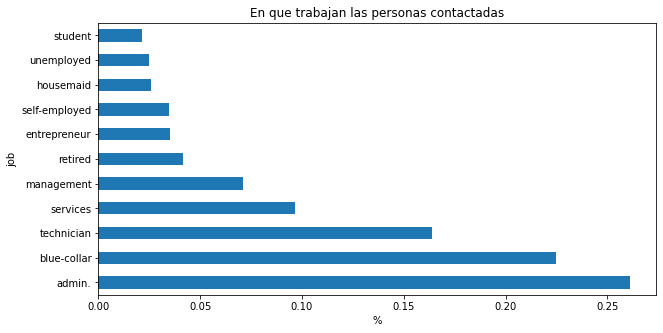

In [22]:
# En que trabajan las personas contactadas
porc_job = df['job'].value_counts()/df.shape[0]
porc_job.plot(kind='barh',figsize=(10,5))
plt.title('En que trabajan las personas contactadas')
plt.ylabel("job")
plt.xlabel('%')
plt.show()



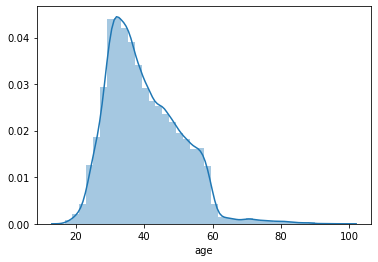

In [23]:
#Distribución de edad de las personas contactadas
sns.distplot(df['age'],bins=40)


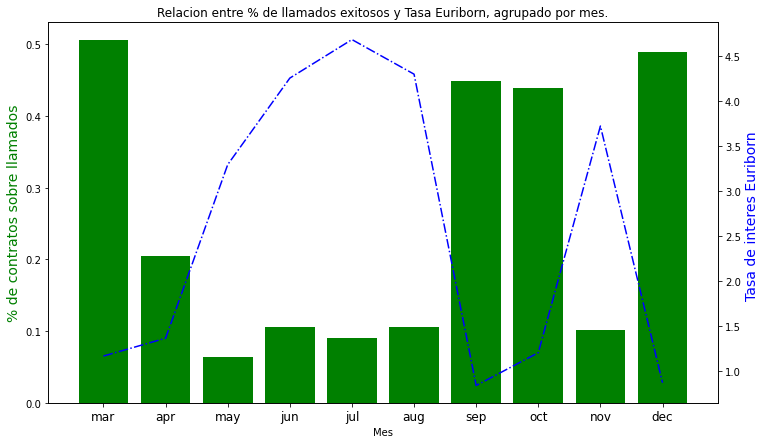

In [24]:
#Relación entre la proporcion de llamados exitosos por mes y el indicador Euriborn que mide la tasa de interes promedio
# De los creditos hipotecarios
months = ['mar', 'apr','may','jun','jul','aug','sep','oct','nov','dec']
prop_month = df['month'][df['y']=='yes'].value_counts()/df['month'].value_counts()
euriborn = df.groupby('month').mean()['euribor3m']

fig, ax1 = plt.subplots(figsize=(12,7))
ax2 = ax1.twinx()
ax1.bar(months, prop_month[months], color='g')
ax2.plot(months, euriborn[months], 'b-.')

ax1.set_xlabel('Mes')
ax1.set_ylabel('% de contratos sobre llamados',color='g', size=14)
ax2.set_ylabel('Tasa de interes Euriborn ', color='b', size= 14)
ax1.set_xticklabels(months,size=12) 
plt.title("Relacion entre % de llamados exitosos y Tasa Euriborn, agrupado por mes.")

plt.show()

Aca podemos observar que existe una relación inversa entre el indice Euriborn y la proporción de llamados exitosos en un mes dado, por lo cual asumismos que el mes sera una variable que tenga un fuerte peso sobre las predicciones. 

### Variables cuantitativas:

In [25]:
#Determinamos cuales son las variables cuantitativas y luego corremos una matriz de correlacion. 
quanty_vars =['age','campaign','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
data1 = df[quanty_vars]
data1.corr('pearson')

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.004594,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
campaign,0.004594,1.000000,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
previous,0.024365,-0.079141,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,0.150754,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.127836,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.013733,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,0.135133,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,0.144095,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


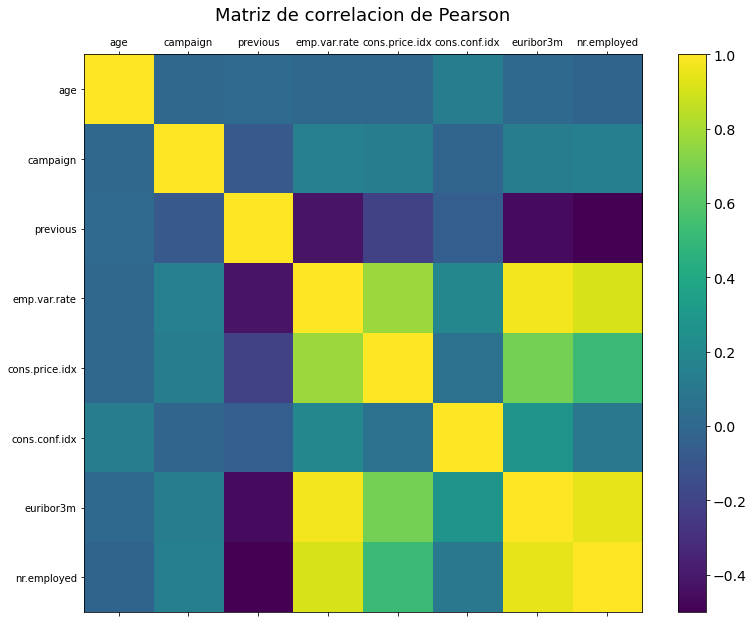

In [26]:
#Mapa de calor de la correlacion de Pearson

f = plt.figure(figsize=(13,10))
plt.matshow(data1.corr(),fignum=f.number)
plt.xticks(range(data1.shape[1]), data1.columns, fontsize=10, rotation=0)
plt.yticks(range(data1.shape[1]), data1.columns, fontsize=10)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Matriz de correlacion de Pearson', fontsize = 18)
plt.show()

Se observa que el a mayor fuerza de trabajo “nr.employed” y por tanto mayor tasa de variación de empleo “emp.var.rate”, crece “cons.price.idx” y el euribor "euribor3m”, principal tipo variable de referencia del mercado hipotecario. Por correlacion podemos pensar que cuando los indicadores economicos suben, tambien sube la tasa de referencia del mercado hipotecario y bajaran nuestras tasas de conversión telefonica. 

## Binarizacion de variables 
Para poder aplicar los distintos modelos, es necesario binarizar las variables categoricas, construyendo las denominadas variables "dummie" que indican la presencia o no de un determinado atributo (1=True, 0=False)

In [27]:
#Elegimos las variables a las cuales le aplicaremos el procedimiento
dummie_columns = ['job','marital','education','education','housing','loan','contact','month','day_of_week',
                  'poutcome','prev.campaign']
df_dummies = pd.get_dummies(df_imputed, columns = dummie_columns)

In [28]:
#Eliminamos las variables sobrantes
column_drops = ['job_student','marital_divorced','education_illiterate','housing_no','loan_no','contact_telephone',
                'month_sep','day_of_week_fri','poutcome_nonexistent','prev.campaign_Week 4']
df_dummies = df_dummies.drop(columns=column_drops)

In [29]:
df_dummies.columns

Index(['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_technician', 'job_unemployed', 'marital_married', 'marital_single',
       'education_basic.4y', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_professional.course',
       'education_university.degree', 'education_basic.4y',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_professional.course', 'education_university.degree',
       'housing_yes', 'loan_yes', 'contact_cellular', 'month_apr', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'day_of_week_mon', 'day_of_week_thu',
       'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure',
    

In [30]:
df_dummies.to_csv('DummiesDataframe.csv')

> ## Division del DataFrame en Xs e Y

In [31]:
#Dividimos el dataframe entre el Dataset en si, y la variable Target "y"
X = df_dummies.drop(columns='y')
y = df_dummies['y']
column_names = X.columns

## Estandarizacion de la variables X
Llevamos todas las variables a la misma escala.

In [32]:
# Utilizaremos el scale() function para estandarizar todas las variables de X.
from sklearn.preprocessing import scale
X = scale(X)
X = pd.DataFrame(X, columns=column_names)
y = pd.DataFrame(y)

## Modelizacion


### Criterio y Metricas a evaluar.

Para poder evaluar la performance de los distintos modelos mediremos distintos indicadores:

* **a) Acurracy (Exactitud):** Hace referencia a la proporcion de predicciones verdadederas. Se medira sobre el train y el test set.
    * Acurracy = (TP + FP)/(TP + FP + TN + FN)
* **b) Precision:** Representa que proporcion de las instancias predichas como 'yes' que realmente lo son. 
    * precision = TP / (TP + FP)
* **c) Recall (recuperación):** Representa que porcentaje de los casos 'yes' son identificados.  
    * recall = TP / (TP + FN)
* **d) Tiempo de ejecución:** Tiempo en segundos de la ejecución del modelo. 

Para nuestro caso concreto, al tratarse de una base da datos desbalanceada, donde el 88 % de los casos tienen un valor de target negativo. El valor de Acurracy no es un indicador adecuado para medir la performance del modelo, ya que partiendo de la base de un modelo nulo en cual predecimos que todos seran negativos, ya conseguimos una acurracy del 88%. 

Lo realmente importante para el caso, es obtener un modelo que me permita poder identificar a la mayor cantidad de individuos que contraten el producto (y='yes'), por lo eligiremos principalmente el modelo que otorge mayor **Recall**, a su vez podemos utilizar el **f1_score**, que ademas de tener en cuenta el **Recall**, utiliza la **Precision** como medida de eficiencia. 


### Importacion de funciones, armado de tablas para evaluación

In [33]:
#Importamos la librerias que estaremos utilizando durante el proceso. 
SEED = 150
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, precision_score,classification_report, f1_score
from sklearn.metrics import roc_curve,roc_auc_score
import time

#Funcion para poder ver bien la Confusion_matrix
def CMatrix(CM, labels=['no','yes']):
    df = pd.DataFrame(data=CM, index=labels, columns=labels)
    df.index.name='TRUE'
    df.columns.name='PREDICTION'
    df.loc['Total'] = df.sum()
    df['Total'] = df.sum(axis=1)
    return df

#Tabla para almacenar las metricas de los modelos. 
metrics = pd.DataFrame(index=['NULL','Logistic_Regression','Decision_Tree','SVC', 'AdaBoost','GradientBoost','Random_Forest'],
                        columns = ['accuracy_train','accuracy_test','precision','recall','f1_score','time','roc_score'])



### División entre Training set y Test set
Realizamos la división del Dataset entre train y test. Al ser un dataset de bastantes registros, guardaremos unicamente un 20% para test.

In [34]:
# Division de la muestra entre train y test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=SEED, stratify=y)

In [35]:
np.shape(X_test)

(12357, 54)

### Ejecución de modelos y medición de la performance
### Modelo nulo o modelo base
En este caso correremos el modelo base, en el cual todas las intancias son predecidas con el valor "no"

In [36]:
y_pred_test = np.repeat('no', y_test.size)
y_pred_train = np.repeat('no', y_train.size)
start = time.time()
model_name = 'NULL'

metrics.loc[model_name,'accuracy_train'] = accuracy_score(y_pred = y_pred_train, y_true=y_train) 
metrics.loc[model_name,'accuracy_test'] = accuracy_score(y_pred = y_pred_test, y_true=y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'time'] = (time.time()- start)

CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


PREDICTION,no,yes,Total
TRUE,,,
no,10965,0,10965
yes,1392,0,1392
Total,12357,0,12357


### 9.4.2 Regresion Logistica
Algoritmo: [L-BFGS](https://es.wikipedia.org/wiki/L-BFGS)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

start = time.time()

logreg = LogisticRegression()

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
# Realizamos la prediciones en la data de testing, guardamos los score en el dataframe
y_pred_test = logreg.predict(X_test)

model_name = 'Logistic_Regression'

metrics.loc[model_name,'accuracy_train'] = logreg.score(X_train, y_train)
metrics.loc[model_name,'accuracy_test'] = logreg.score(X_test, y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'time'] = (time.time()- start)

y_pred_prob = logreg.predict_proba(X_test)[:,1]
metrics.loc[model_name,'roc_score'] = roc_auc_score(y_test, y_pred_prob)

#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)



/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


PREDICTION,no,yes,Total
TRUE,,,
no,10795,170,10965
yes,1062,330,1392
Total,11857,500,12357


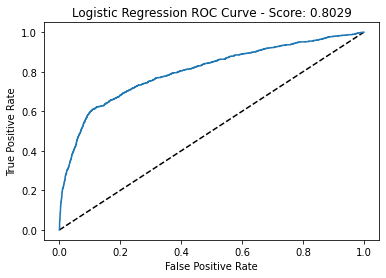

In [38]:
y_pred_prob = logreg.predict_proba(X_test)[:,1]
model_name = 'Logistic Regression'
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob,pos_label='yes')
plt.plot([0, 1], [0, 1],
'k--')

plt.plot(fpr, tpr, label=model_name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
score= roc_auc_score(y_test, y_pred_prob)
plt.title(model_name + ' ROC Curve - Score: ' + str(round(score,4)))
plt.show();

### Observaciones:
* **Acurracy:** 90.02%
* **Precision:** 65.86%
* **Recall:** 23.71%
* **F1-Score:** 34.86%
* **Roc_AUC_Score:** 80.29%

## 9.4.3 Arbol de decision:

Algoritmo: Version optimizada de [CART](https://scikit-learn.org/stable/modules/tree.html)

In [39]:
# importamos el modulo necesario
from sklearn.tree import DecisionTreeClassifier

start = time.time()

# Creamos el clasificador: logreg
dec_tree = DecisionTreeClassifier( max_depth=5, random_state=SEED )

# Entrenamos el modelo con la data de training
dec_tree.fit(X_train, y_train)

# Realizamos la prediciones en la data de testing, guardamos los score en el dataframe
y_pred_test = dec_tree.predict(X_test)
model_name = 'Decision_Tree'
metrics.loc[model_name,'accuracy_train'] = dec_tree.score(X_train, y_train)
metrics.loc[model_name,'accuracy_test'] = dec_tree.score(X_test, y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'time'] = (time.time()- start)

y_pred_prob = dec_tree.predict_proba(X_test)[:,1]
metrics.loc[model_name,'roc_score'] = roc_auc_score(y_test, y_pred_prob)

#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)

PREDICTION,no,yes,Total
TRUE,,,
no,10684,281,10965
yes,980,412,1392
Total,11664,693,12357


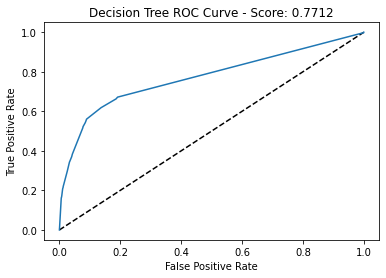

In [40]:
y_pred_prob = dec_tree.predict_proba(X_test)[:,1]
model_name = 'Decision Tree'
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob,pos_label='yes')
plt.plot([0, 1], [0, 1],
'k--')
plt.plot(fpr, tpr, label=model_name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
score= roc_auc_score(y_test, y_pred_prob)
plt.title(model_name + ' ROC Curve - Score: ' + str(round(score,4)))
plt.show();

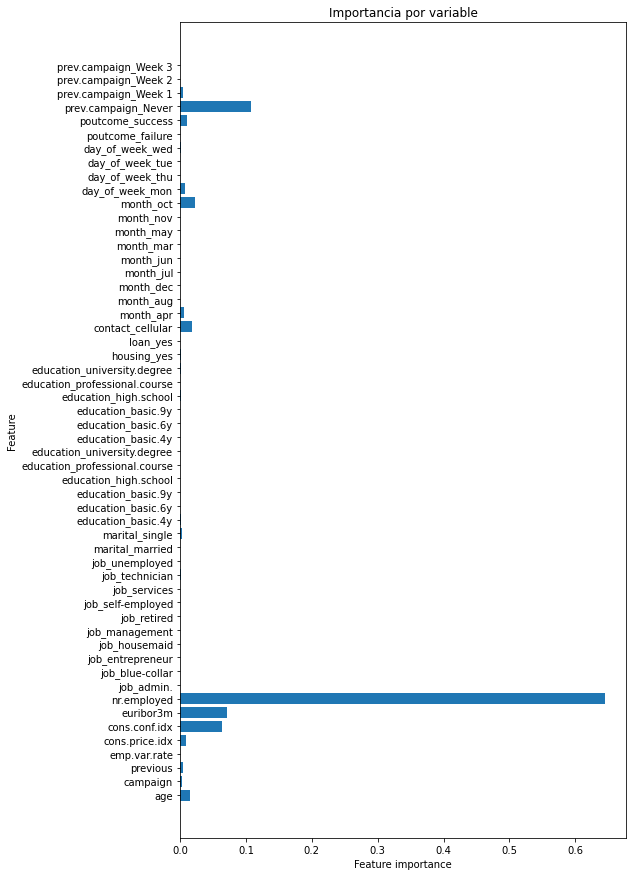

In [41]:
def plot_feature_importances(model):
    n_features = X.shape[1]
    plt.figure(figsize=(8,15))
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.title("Importancia por variable")
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
plot_feature_importances(dec_tree)

Aca podemos observar las variables junt que pondero este arbol especifico para hacer las reglas del modelo. Esto no significa que sean las unicas significativas, sino que son las que selecciono este arbol. 

### Observaciones:
* **Acurracy:** 89.79%
* **Precision:** 59.45%
* **Recall:** 29.60%
* **F1-Score:** 39.52% 
* **Roc_AUC_Score:** 77.12%

### 9.4.4 Support Vector Machine Classifier
Algoritmo = [rbf](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html?highlight=svc#sklearn.svm.SVC)

In [42]:
from sklearn.svm import SVC

start = time.time()

svc = SVC()

# Entrenamos el modelo con la data de training
svc.fit(X_train, y_train)

# Realizamos la prediciones en la data de testing, guardamos los score en el dataframe
y_pred_test = svc.predict(X_test)
model_name = 'SVC'
metrics.loc[model_name,'accuracy_train'] = svc.score(X_train, y_train)
metrics.loc[model_name,'accuracy_test'] = svc.score(X_test, y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'time'] = (time.time()- start)

#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


PREDICTION,no,yes,Total
TRUE,,,
no,10800,165,10965
yes,1069,323,1392
Total,11869,488,12357


### Observaciones:
* **Acurracy:** 90.01%
* **Precision:** 66.18%
* **Recall:** 23.20%
* **F1-Score:** 34.36%
* **Roc_AUC_Score:** No calculado por su largo tiempo de ejecución 

### 9.4.5 Adaptive Boosting
Algoritmo: [SAMME.R](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)


In [43]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

start = time.time()

dt = DecisionTreeClassifier(max_depth=1, random_state=SEED)
adb_clf = AdaBoostClassifier(base_estimator=dt, n_estimators=100)

# Entrenamos el modelo con la data de training
adb_clf.fit(X_train, y_train)

# Realizamos la prediciones en la data de testing, guardamos los score en el dataframe
y_pred_test = adb_clf.predict(X_test)
model_name = 'AdaBoost'
metrics.loc[model_name,'accuracy_train'] = adb_clf.score(X_train, y_train)
metrics.loc[model_name,'accuracy_test'] = adb_clf.score(X_test, y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')

y_pred_prob = adb_clf.predict_proba(X_test)[:,1]
metrics.loc[model_name,'roc_score'] = roc_auc_score(y_test, y_pred_prob)
metrics.loc[model_name,'time'] = (time.time()- start)

#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


PREDICTION,no,yes,Total
TRUE,,,
no,10813,152,10965
yes,1061,331,1392
Total,11874,483,12357


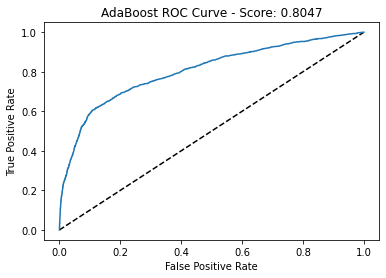

In [44]:
model_name = 'AdaBoost'
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob,pos_label='yes')
plt.plot([0, 1], [0, 1],
'k--')
plt.plot(fpr, tpr, label=model_name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
score= roc_auc_score(y_test, y_pred_prob)
plt.title(model_name + ' ROC Curve - Score: ' + str(round(score,4)))
plt.show();

### Observaciones:
* **Acurracy:** 90.18% 
* **Precision:** 68.53%
* **Recall:** 23.77%
* **F1-Score:** 53.06%
* **Roc_AUC_Score:** 80.47%

### 9.4.6 Gradient Boosting
Algoritmo: [Version modificada de AdaBoost](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

start = time.time()

gbrt = GradientBoostingClassifier(max_depth=5, random_state=0)

gbrt.fit(X_train, y_train)

# Realizamos la prediciones en la data de testing, guardamos los score en el dataframe
y_pred_test = adb_clf.predict(X_test)
model_name = 'GradientBoost'
metrics.loc[model_name,'accuracy_train'] = gbrt.score(X_train, y_train)
metrics.loc[model_name,'accuracy_test'] = gbrt.score(X_test, y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')

y_pred_prob = adb_clf.predict_proba(X_test)[:,1]
metrics.loc[model_name,'roc_score'] = roc_auc_score(y_test, y_pred_prob)
metrics.loc[model_name,'time'] = (time.time()- start)

#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


PREDICTION,no,yes,Total
TRUE,,,
no,10813,152,10965
yes,1061,331,1392
Total,11874,483,12357


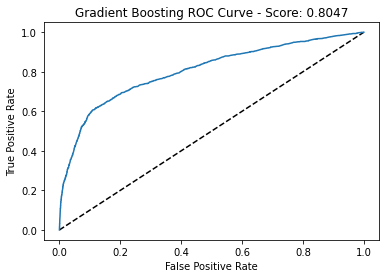

In [46]:
model_name = 'Gradient Boosting'
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob,pos_label='yes')
plt.plot([0, 1], [0, 1],
'k--')
plt.plot(fpr, tpr, label=model_name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
score= roc_auc_score(y_test, y_pred_prob)
plt.title(model_name + ' ROC Curve - Score: ' + str(round(score,4)))
plt.show();

### Observaciones:
* **Acurracy:** 90.24%
* **Precision:** 68.53%
* **Recall:** 23.77%
* **F1-Score:** 35.30%
* **Roc_AUC_Score:** 80.47%

### Random Forest
Algoritmo: [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

In [47]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500,n_jobs=-1,random_state=SEED)

start = time.time()
# Fit 'rf' to the training set
rf.fit(X_train, y_train)
# Predict the test set labels 'y_pred'

y_pred_test = rf.predict(X_test)
model_name = 'Random_Forest'
metrics.loc[model_name,'accuracy_train'] = rf.score(X_train, y_train)
metrics.loc[model_name,'accuracy_test'] = rf.score(X_test, y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')


y_pred_prob = rf.predict_proba(X_test)[:,1]
metrics.loc[model_name,'roc_score'] = roc_auc_score(y_test, y_pred_prob)
metrics.loc[model_name,'time'] = (time.time()- start)

#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  


PREDICTION,no,yes,Total
TRUE,,,
no,10594,371,10965
yes,959,433,1392
Total,11553,804,12357


In [48]:
metrics

,accuracy_train,accuracy_test,precision,recall,f1_score,time,roc_score
NULL,0.887343,0.887351,0,0,0,0.581048,NaN
Logistic_Regression,0.900385,0.900299,0.66,0.237069,0.348837,1.23907,0.802874
Decision_Tree,0.901738,0.897953,0.594517,0.295977,0.395204,0.869402,0.771243
SVC,0.908675,0.900138,0.661885,0.23204,0.343617,143.236,NaN
AdaBoost,0.90042,0.901837,0.6853,0.237787,0.353067,11.2214,0.804722
GradientBoost,0.916826,0.902565,0.6853,0.237787,0.353067,9.47069,0.804722
Random_Forest,0.995318,0.892369,0.538557,0.311063,0.394353,10.7755,0.780382


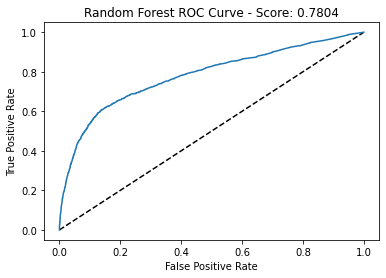

In [49]:
model_name = 'Random Forest'
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob,pos_label='yes')
plt.plot([0, 1], [0, 1],
'k--')
plt.plot(fpr, tpr, label=model_name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
score= roc_auc_score(y_test, y_pred_prob)
plt.title(model_name + ' ROC Curve - Score: ' + str(round(score,4)))
plt.show();

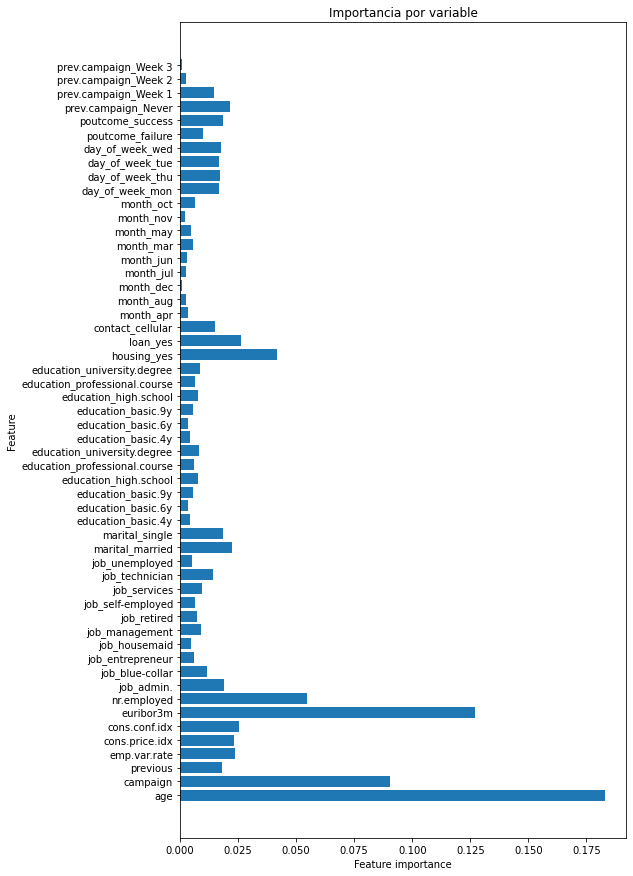

In [50]:

def plot_feature_importances(model):
    n_features = X.shape[1]
    plt.figure(figsize=(8,15))
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.title("Importancia por variable")
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
plot_feature_importances(rf)

Podemos observar como el Random Forest toma la ponderacion de las variables de los 500 arboles.

### Observaciones:
* **Acurracy:** 89.23%
* **Precision:** 53.85%
* **Recall** 31.10%
* **F1-Score** 39.43%
* **Roc_AUC_Score:** 78.03%

# XGBoost

In [51]:
duplicate_columns = X_train.columns[X_train.columns.duplicated()]
duplicate_columns

Index(['education_basic.4y', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_professional.course',
       'education_university.degree'],
      dtype='object')

In [52]:
X_train = X_train.loc[:,~X_train.columns.duplicated()]
X_test = X_test.loc[:,~X_test.columns.duplicated()]

In [53]:
X_train.to_csv('train_data.csv')

In [54]:
import xgboost as xgb
gbm = xgb.XGBClassifier(max_depth=3, n_estimators=300, learning_rate=0.05)

start = time.time()
# Fit 'rf' to the training set
gbm.fit(X_train, y_train)
# Predict the test set labels 'y_pred'

y_pred_test = gbm.predict(X_test)
model_name = 'XGBoost'
metrics.loc[model_name,'accuracy_train'] = gbm.score(X_train, y_train)
metrics.loc[model_name,'accuracy_test'] = gbm.score(X_test, y_test) 
metrics.loc[model_name,'precision'] = precision_score(y_test, y_pred_test, pos_label='yes')
metrics.loc[model_name,'recall'] = recall_score(y_test, y_pred_test,pos_label='yes')
metrics.loc[model_name,'f1_score'] = f1_score(y_test, y_pred_test,pos_label='yes')


y_pred_prob = gbm.predict_proba(X_test)[:,1]
metrics.loc[model_name,'roc_score'] = roc_auc_score(y_test, y_pred_prob)
metrics.loc[model_name,'time'] = (time.time()- start)

#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = y_pred_test, y_true=y_test )
CMatrix(CM)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


PREDICTION,no,yes,Total
TRUE,,,
no,10780,185,10965
yes,1048,344,1392
Total,11828,529,12357


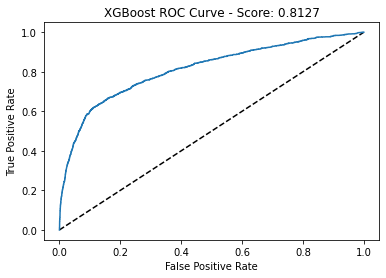

In [55]:
model_name = 'XGBoost'
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob,pos_label='yes')
plt.plot([0, 1], [0, 1],
'k--')
plt.plot(fpr, tpr, label=model_name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
score= roc_auc_score(y_test, y_pred_prob)
plt.title(model_name + ' ROC Curve - Score: ' + str(round(score,4)))
plt.show();

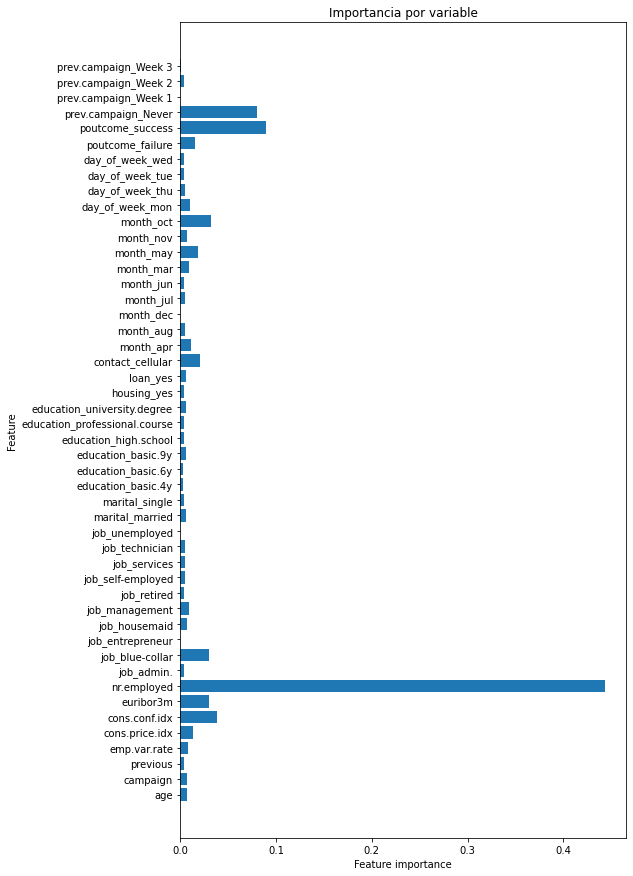

In [56]:
def plot_feature_importances(model):
    n_features = X_train.shape[1]
    plt.figure(figsize=(8,15))
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X_train.columns)
    plt.title("Importancia por variable")
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
plot_feature_importances(gbm)

In [57]:
metrics

,accuracy_train,accuracy_test,precision,recall,f1_score,time,roc_score
NULL,0.887343,0.887351,0,0,0,0.581048,NaN
Logistic_Regression,0.900385,0.900299,0.66,0.237069,0.348837,1.23907,0.802874
Decision_Tree,0.901738,0.897953,0.594517,0.295977,0.395204,0.869402,0.771243
SVC,0.908675,0.900138,0.661885,0.23204,0.343617,143.236,NaN
AdaBoost,0.90042,0.901837,0.6853,0.237787,0.353067,11.2214,0.804722
GradientBoost,0.916826,0.902565,0.6853,0.237787,0.353067,9.47069,0.804722
Random_Forest,0.995318,0.892369,0.538557,0.311063,0.394353,10.7755,0.780382
XGBoost,0.903992,0.900218,0.650284,0.247126,0.358147,5.58733,0.812732


# Redes Neuronales. Perceptron

In [58]:
# transformamos en matriz a los datos de entrenamiento y testing
traindata = np.asmatrix(X_train)
print(traindata.shape)
testdata = np.asmatrix(X_test)
print(testdata.shape)
trainlabels= np.where(y_train=='yes', 1, 0)
testlabels= np.where(y_test=='yes', 1, 0)
print(trainlabels.shape)
print(testlabels.shape)




(28831, 48)
(12357, 48)
(28831, 1)
(12357, 1)


In [59]:
# generamos la matriz de pesos, tenemos que tener un peso por cada uno de las variables
# independientes y dos filas para las categorías a pronosticar
weights = np.zeros((2,48))
print(weights.shape)

(2, 48)


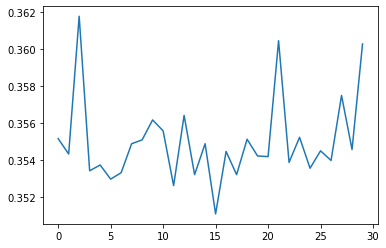

In [60]:
# For E epochs, 
E = 30
errors = []
for epoch in range(E):
    err = 0 #reset the error counter
    # Para cada registro empezamos a calcular el error,
    for i, x in enumerate(traindata):
        dp=[] #creamos un nuevo conjunto que va a ir generando la estimación para cada registro
        # Para cada clase (0,1) estimamos el valor y el desvío
        for w in weights:
            dotproduct = np.dot(x,w) #realizamos la productoria entre variables y pesos
            dp.append(dotproduct) #agregamos el resultado al conjunto que creamos
        guess = np.argmax(dp) #tomamos el mayor valor de la estimación para cada registro y le asignamos la clase
        actual = trainlabels[i]
        # Si la estimación se desvía del valor real, actualizamos el vector de pesos
        if guess != actual:
            weights[guess] = weights[guess] - x #actualizamos el incorrecto de los pesos del vector
            weights[actual] = weights[actual] + x #actualizamos el correcto
            err += 1
    errors.append(err/28831) #trackeamos la cantidad de errores luego de pasar por todo el dataset
plt.plot(list(range(0,E)),errors) #hacemos un plot para ver la tasa de error de las distintas épocas

In [61]:
guesses = []
for i, z in enumerate(testdata):
    dp=[] #creamos un nuevo contenedor de datos
    # para cada clase
    for w in weights:
        dotproduct = np.dot(z,w) #a partir de los pesos finales w estimamos los valores de cada punto
        dp.append(dotproduct) #los agregamos
    guess = np.argmax(dp) #tomamos el valor máximo de esta multiplicación
    guesses.append(guess)
    

In [62]:
#Imprime la matriz de contingencias
CM = confusion_matrix(y_pred = guesses, y_true=testlabels )
CMatrix(CM)

PREDICTION,no,yes,Total
TRUE,,,
no,7447,3518,10965
yes,628,764,1392
Total,8075,4282,12357


In [63]:
trainlabels

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [64]:
from sklearn.linear_model import Perceptron
Perceptron = Perceptron(eta0=0.0001, alpha=0.2, random_state=0)
Perceptron.fit(traindata,trainlabels)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


Perceptron(alpha=0.2, eta0=0.0001)

In [65]:
y_pred_test = Perceptron.predict(testdata)
model_name = 'Perceptron'
metrics.loc[model_name,'accuracy_train'] = Perceptron.score(traindata,trainlabels)
metrics.loc[model_name,'accuracy_test'] = Perceptron.score(testdata, testlabels) 
metrics.loc[model_name,'precision'] = precision_score(testlabels, y_pred_test, pos_label=1)
metrics.loc[model_name,'recall'] = recall_score(testlabels, y_pred_test,pos_label=1)
metrics.loc[model_name,'f1_score'] = f1_score(testlabels, y_pred_test,pos_label=1)


from sklearn.calibration import CalibratedClassifierCV
clf_isotonic = CalibratedClassifierCV(Perceptron, cv=10, method='isotonic')
clf_isotonic.fit(traindata,trainlabels)
y_pred_prob = clf_isotonic.predict_proba(testdata)[:,1]
metrics.loc[model_name,'roc_score'] = roc_auc_score(y_test, y_pred_prob)
metrics.loc[model_name,'time'] = (time.time()- start)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


## Eleccion de modelo


### Metricas sobre los modelos

In [66]:
metrics

,accuracy_train,accuracy_test,precision,recall,f1_score,time,roc_score
NULL,0.887343,0.887351,0,0,0,0.581048,NaN
Logistic_Regression,0.900385,0.900299,0.66,0.237069,0.348837,1.23907,0.802874
Decision_Tree,0.901738,0.897953,0.594517,0.295977,0.395204,0.869402,0.771243
SVC,0.908675,0.900138,0.661885,0.23204,0.343617,143.236,NaN
AdaBoost,0.90042,0.901837,0.6853,0.237787,0.353067,11.2214,0.804722
GradientBoost,0.916826,0.902565,0.6853,0.237787,0.353067,9.47069,0.804722
Random_Forest,0.995318,0.892369,0.538557,0.311063,0.394353,10.7755,0.780382
XGBoost,0.903992,0.900218,0.650284,0.247126,0.358147,5.58733,0.812732
Perceptron,0.85311,0.851258,0.345354,0.357759,0.351447,46.0429,0.74875


### Accuracy

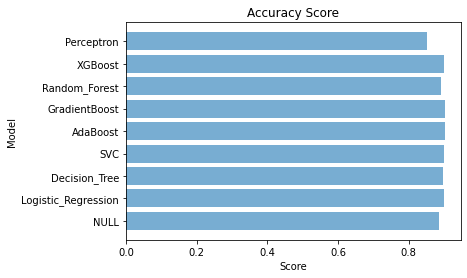

In [67]:
plt.barh(np.arange(metrics.shape[0]),metrics.accuracy_test, align='center',alpha = 0.6)
plt.title('Accuracy Score')
plt.yticks(np.arange(metrics.shape[0]),metrics.index )
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()

Como dijimos antes, esta no sera una metrica importante, ya que todo modelo tendra una accuracy mayor a 88% que es el acurracy del modelo base.

### Precision

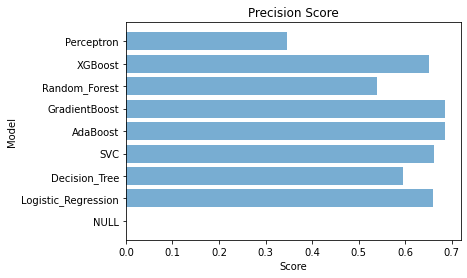

In [68]:
plt.barh(np.arange(metrics.shape[0]),metrics.precision, align='center',alpha = 0.6)
plt.title('Precision Score')
plt.yticks(np.arange(metrics.shape[0]),metrics.index)
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()

El modelo con mayor precision es el Adaboost y Gradient Boost con una precision de 68%, esto significa de los casos que identifica como clientes que contratan el servicio. El 68% tendran un resultado positivo. 

### Recall

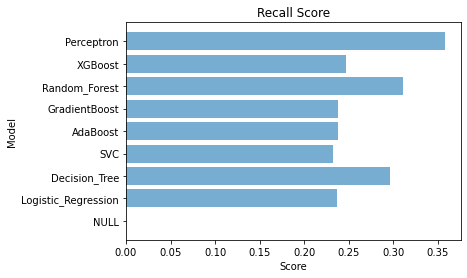

In [69]:
plt.barh(np.arange(metrics.shape[0]),metrics.recall, align='center',alpha = 0.6)
plt.title('Recall Score')
plt.yticks(np.arange(metrics.shape[0]),metrics.index)
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()

Esta fue una de las metricas de mayor importancia para nuestro caso, en este caso, Random forest es el modelo que otorga mayor Recall del 31%, siendo el modelo que identifica mas clientes. 

### F1 Score

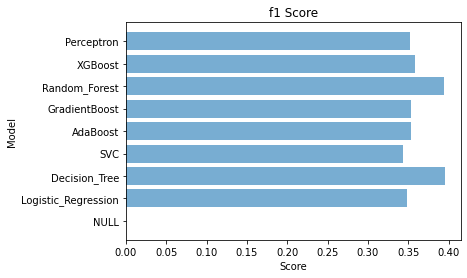

In [70]:

plt.barh(np.arange(metrics.shape[0]),metrics.f1_score, align='center',alpha = 0.6)
plt.title('f1 Score')
plt.yticks(np.arange(metrics.shape[0]),metrics.index)
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()

El f1_score nos indica un igual valor para random forest y decision tree simple. Esto nos indica que existe una buena relacion entre recall y precision, y estos son los modelos que mas optimizan las llamadas. 

### Eleccion de Modelo

La eleccion final del modelo dependera de los objetivos y de los ingresos y costos asociados a la adquisicion de un nuevo cliente. Pero en principio el analisis hecho nos indica que: 

* Utilizando Random Forest (Mayor recall y f1 score): Si llamamos un 6.5% de la base obtendriamos un 31.10% de los clientes.

* Si se cuenta con mas recursos y se quiere invertir en adquirir el resto de los clientes se puede utilizar el modelo para ordenar por probabilidad el resto de los clientes a llamar. (Utilizamos la funcion model.predict_proba() sobre un nuevo test set y ordenamos de mayor a menor para hacer los llamados). 

* En caso de que se opte por seguir haciendo llamados se debe hacer un adecuando analisis de costo de adquisicion de cliente.

Se debe decidir entre: 

a) Si llamar 2680 clientes y vender 1443 creditos (Calculandos sus ingresos y costos asociados) 

b) Si llamar 41118 clientes y convertir 4640 clientes (Calculandos sus ingresos y costos asociados) 

c) Mix entre a y b, priorizando llamandos con a

